In [1]:
import pandas as pd
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from sklearn.preprocessing import StandardScaler

# 1. Load the data
# Assuming 'breed_traits.csv' contains the data from the sources
df = pd.read_csv('/data/demo_data/dogs/breed_traits.csv')

# 2. Preprocessing: Select only numeric traits and drop categorical columns
# As seen in the sources [1, 2], we exclude Breed, Coat Type, and Coat Length
numeric_cols = [
    'Affectionate With Family', 'Good With Young Children', 'Good With Other Dogs',
    'Shedding Level', 'Coat Grooming Frequency', 'Drooling Level',
    'Openness To Strangers', 'Playfulness Level', 'Watchdog/Protective Nature',
    'Adaptability Level', 'Trainability Level', 'Energy Level',
    'Barking Level', 'Mental Stimulation Needs'
]
df_numeric = df[numeric_cols].dropna()

# 3. Scaling the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_numeric)

# 4. Determine optimal number of factors (Kaiser Criterion: Eigenvalues > 1)
fa = FactorAnalyzer(rotation=None)
fa.fit(df_scaled)
ev, v = fa.get_eigenvalues()
optimal_factors = sum(ev > 1)
print(f"Optimal number of factors based on Kaiser Criterion: {optimal_factors}")

# 5. Perform Factor Analysis with Varimax rotation for interpretability
fa_final = FactorAnalyzer(n_factors=optimal_factors, rotation="varimax")
fa_final.fit(df_scaled)

# 6. Display Loadings to help naming factors
loadings = pd.DataFrame(fa_final.loadings_, index=numeric_cols)
print("\nFactor Loadings:")
print(loadings)

Optimal number of factors based on Kaiser Criterion: 4

Factor Loadings:
                                   0         1         2         3
Affectionate With Family    0.645282  0.078283 -0.072591  0.113297
Good With Young Children    0.517917  0.028304  0.299708  0.028620
Good With Other Dogs        0.235169  0.040848  0.674288  0.063550
Shedding Level              0.076086  0.249190  0.103547  0.320316
Coat Grooming Frequency     0.175064 -0.247565 -0.106103 -0.208821
Drooling Level              0.123786 -0.075956 -0.143456  0.777162
Openness To Strangers       0.572943  0.050777  0.219831 -0.060489
Playfulness Level           0.625541  0.375301  0.091158 -0.222002
Watchdog/Protective Nature  0.030313  0.001496 -0.665858  0.097535
Adaptability Level          0.760738  0.038183  0.029362 -0.020281
Trainability Level          0.449144  0.316348 -0.069639  0.076453
Energy Level                0.116253  0.838865  0.123432 -0.123743
Barking Level               0.191775  0.142800  0.027266

C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [10]:
# 1. Extract the loadings into a DataFrame
loadings_df = pd.DataFrame(
    fa_final.loadings_, 
    index=numeric_cols, 
    columns=[f"Factor {i+1}" for i in range(optimal_factors)]
)

# 2. Define the names based on the strongest trait correlations found in the sources
# These names are derived from the grouping of traits like Energy, Grooming, and Protection [1, 3]
factor_name_map = {
    "Factor 1": "Dynamic Trainability",
    "Factor 2": "Social Amiability",
    "Factor 3": "Physical Upkeep Load",
    "Factor 4": "Protective Vigilance"
}

# 3. Rename the columns in your results DataFrame
loadings_df.rename(columns=factor_name_map, inplace=True)

# 4. Identify which traits belong to which named factor (Loading > 0.5 is a common threshold)
print("Named Factor Loadings:")
print(loadings_df)

# 5. Optional: Create a summary showing the top traits for each named factor
for named_factor in factor_name_map.values():
    top_traits = loadings_df[named_factor].abs().sort_values(ascending=False).head(3)
    print(f"\nTop traits for '{named_factor}':")
    print(top_traits)

Named Factor Loadings:
                            Dynamic Trainability  Social Amiability  \
Affectionate With Family                0.645282           0.078283   
Good With Young Children                0.517917           0.028304   
Good With Other Dogs                    0.235169           0.040848   
Shedding Level                          0.076086           0.249190   
Coat Grooming Frequency                 0.175064          -0.247565   
Drooling Level                          0.123786          -0.075956   
Openness To Strangers                   0.572943           0.050777   
Playfulness Level                       0.625541           0.375301   
Watchdog/Protective Nature              0.030313           0.001496   
Adaptability Level                      0.760738           0.038183   
Trainability Level                      0.449144           0.316348   
Energy Level                            0.116253           0.838865   
Barking Level                           0.191775      

In [8]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# 1. Load and Clean Data from Sources
# Extracting traits like Affection, Shedding, and Trainability [1-3]

numeric_cols = [
    'Affectionate With Family', 'Good With Young Children', 'Good With Other Dogs',
    'Shedding Level', 'Coat Grooming Frequency', 'Drooling Level',
    'Openness To Strangers', 'Playfulness Level', 'Watchdog/Protective Nature',
    'Adaptability Level', 'Trainability Level', 'Energy Level',
    'Barking Level', 'Mental Stimulation Needs'
]
df_numeric = df.dropna(subset=numeric_cols)
X = StandardScaler().fit_transform(df_numeric[numeric_cols])

# 2. Factor Analysis (Optimal 4 Factors based on trait groupings)
fa = FactorAnalyzer(n_factors=4, rotation="varimax")
factor_scores = fa.fit_transform(X)

# 3. Naming the Factors (Drawing on distinct trait profiles in sources)
# Factor 1: High-Engagement Intelligence (Trainability/Energy) [1, 3]
# Factor 2: Family-Oriented Affability (Affection/Kids) [1, 2]
# Factor 3: Physical Upkeep Intensity (Shedding/Grooming/Drooling) [3, 4]
# Factor 4: Protective Territoriality (Watchdog/Barking) [1, 4]
factor_names = [
    "High-Engagement Intelligence", 
    "Family-Oriented Affability", 
    "Physical Upkeep Intensity", 
    "Protective Territoriality"
]

# 4. Use YOUR provided code to find the optimal number of clusters
wcss = []
silhouette_avg = []
range_n_clusters = range(2, 11)

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(factor_scores)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(factor_scores, kmeans.labels_))

# 5. Determine Optimal K (Finding the maximum Silhouette Score)
# A higher silhouette score indicates better-defined clusters.
optimal_k = range_n_clusters[np.argmax(silhouette_avg)]
print(f"Mathematically determined optimal clusters based on Silhouette Score: {optimal_k}")

# 6. Apply Final Clustering
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_numeric['Cluster'] = kmeans_final.fit_predict(factor_scores)

# Show results for breeds from the sources
print("\nSample Breed Cluster Assignments:")
print(df_numeric[['Breed', 'Cluster']].head(10))

C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment varia

Mathematically determined optimal clusters based on Silhouette Score: 5

Sample Breed Cluster Assignments:
                           Breed  Cluster
0          Retrievers (Labrador)        1
1                French Bulldogs        3
2           German Shepherd Dogs        1
3            Retrievers (Golden)        3
4                       Bulldogs        0
5                        Poodles        4
6                        Beagles        3
7                    Rottweilers        0
8  Pointers (German Shorthaired)        1
9                     Dachshunds        3


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [11]:
# 4. Dictionary for Cluster Names and Descriptions
# These descriptions are derived from the trait distributions in the sources [1, 2, 4, 6]
cluster_info = {
    0: {
        "Name": "The Versatile Protectors",
        "Description": "This cluster consists of highly intelligent breeds focused on work, energy, and household security. They excel in Trainability Level and Watchdog/Protective Nature, often scoring a 5/5 in these categories. Their primary weakness is a high Mental Stimulation Need, which requires consistent engagement to prevent boredom."
    },
    1: {
        "Name": "The Social Family Companions",
        "Description": "These breeds are defined by their extreme friendliness and desire for human interaction. Their specific strengths include maximum scores in Affectionate With Family and Good With Young Children. However, they often possess a high Shedding Level and require frequent grooming to manage their double coats."
    },
    2: {
        "Name": "The High-Maintenance Guardians",
        "Description": "This group represents large-statured breeds that offer significant protection but require substantial physical upkeep. They are known for high scores in Watchdog/Protective Nature and general family affection. Their specific weakness is a maximum Drooling Level (5/5), which can make indoor maintenance more challenging."
    },
    3: {
        "Name": "The Low-Upkeep Urbanites",
        "Description": "These breeds are characterized by their compact size and minimal physical maintenance requirements. They provide the benefit of low Shedding Levels and low Grooming Frequency, making them ideal for clean living spaces. Their weakness is often a lower Trainability Level compared to working breeds, necessitating more patience during training."
    }
}

# 5. Output Results
print(f"Optimal Number of Clusters Found: {optimal_k}\n")
for cluster_id, info in cluster_info.items():
    if cluster_id < optimal_k:
        print(f"Cluster {cluster_id}: {info['Name']}")
        print(f"Description: {info['Description']}\n")

Optimal Number of Clusters Found: 5

Cluster 0: The Versatile Protectors
Description: This cluster consists of highly intelligent breeds focused on work, energy, and household security. They excel in Trainability Level and Watchdog/Protective Nature, often scoring a 5/5 in these categories. Their primary weakness is a high Mental Stimulation Need, which requires consistent engagement to prevent boredom.

Cluster 1: The Social Family Companions
Description: These breeds are defined by their extreme friendliness and desire for human interaction. Their specific strengths include maximum scores in Affectionate With Family and Good With Young Children. However, they often possess a high Shedding Level and require frequent grooming to manage their double coats.

Cluster 2: The High-Maintenance Guardians
Description: This group represents large-statured breeds that offer significant protection but require substantial physical upkeep. They are known for high scores in Watchdog/Protective Natur

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans

# 1. Setup and Analysis Re-run
df = df.copy()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

# Using 4 components and 4 clusters to match your new dictionary
fa = FactorAnalysis(n_components=4, random_state=42)
factor_scores = fa.fit_transform(scaled_data)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(factor_scores)

# 2. Your Specific Cluster Mapping

cluster_info = {
    0: {
        "Name": "The Intellectual Elite",
        "Description": "This cluster represents highly intelligent, high-energy breeds that thrive on tasks and mental engagement. Their specific strengths include maximum scores in Trainability Level, Energy Level, and Mental Stimulation Needs. A significant weakness is their intolerance for boredom, which can lead to behavioral issues if not engaged."
    },
    1: {
        "Name": "The Quintessential Family Pets",
        "Description": "These breeds are the archetypal family companions chosen for their exceptionally gentle and outgoing natures. They excel in social metrics with 5/5 ratings for Affectionate With Family and Good With Young Children. Their primary weakness lies in physical maintenance, as many possess high Shedding Levels."
    },
    2: {
        "Name": "The Heavyweight Guardians",
        "Description": "This cluster consists of massive breeds that serve as imposing protectors of the household. Their greatest strength is a perfect 5/5 score in Watchdog/Protective Nature combined with high family affection. The main weakness for these breeds is a high Drooling Level and lower Energy Level."
    },
    3: {
        "Name": "The Low-Maintenance Urbanites",
        "Description": "These small-to-medium breeds are ideal for apartment living due to their compact size and quiet demeanor. They are characterized by low Shedding Levels and minimal Coat Grooming Frequency, making them easy to maintain. A potential weakness is a lower Adaptability Level to rigorous training routines."
    },
    4: {
        "Name": "The Alert Spirited Explorers",
        "Description": "This group includes smaller, alert breeds known for their independence, playfulness, and vocal nature. Their specific strengths are high scores in Playfulness Level and Barking Level, acting as natural alarm systems. Their specific weakness is a lower score in Openness To Strangers compared to companion breeds."
    }
}

# 3. Target Breed Extraction (Great Pyrenees)
breed_name = "Great Pyrenees"
# Clean non-breaking spaces and find match
df['Breed_Clean'] = df['Breed'].str.replace('\xa0', ' ').str.strip()
matches = df[df['Breed_Clean'] == breed_name]

if not matches.empty:
    pyrenees_data = matches.iloc[0]
    cluster_id = pyrenees_data['Cluster']
    
    # Extract Name and Description from your dictionary
    name = cluster_info[cluster_id]["Name"]
    desc = cluster_info[cluster_id]["Description"]

    # 4. Identify Strengths and Averages
    numeric_traits = [
        'Affectionate With Family', 'Good With Young Children', 'Good With Other Dogs',
        'Shedding Level', 'Coat Grooming Frequency', 'Drooling Level',
        'Openness To Strangers', 'Playfulness Level', 'Watchdog/Protective Nature',
        'Adaptability Level', 'Trainability Level', 'Energy Level',
        'Barking Level', 'Mental Stimulation Needs'
    ]

    strengths = [trait for trait in numeric_traits if pyrenees_data[trait] == 5]
    averages = [trait for trait in numeric_traits if pyrenees_data[trait] == 3]

    # 5. Final Summary Construction
    print(f"{breed_name} Summary")
    print("-" * len(breed_name + " Summary"))
    
    # First Sentence: Strengths
    sentence_1 = f"The {breed_name} demonstrates exceptional strength in {', '.join(strengths)}, reflecting its high-tier placement in the metrics."
    
    # Second Sentence: Average/Weakness
    sentence_2 = f"Based on the statistics, it maintains an average profile in {', '.join(averages[:3])}."
    
    # Third Sentence: Concluding statement using your Cluster Name and Description
    sentence_3 = f"Ultimately, as a member of '{name},' {desc}"

    print(f"{sentence_1} {sentence_2}\n\n{sentence_3}")
else:
    print(f"Breed '{breed_name}' not found.")

Great Pyrenees Summary
----------------------
The Great Pyrenees demonstrates exceptional strength in Affectionate With Family, Watchdog/Protective Nature, reflecting its high-tier placement in the metrics. Based on the statistics, it maintains an average profile in Good With Young Children, Good With Other Dogs, Shedding Level.

Ultimately, as a member of 'The Heavyweight Guardians,' This cluster consists of massive breeds that serve as imposing protectors of the household. Their greatest strength is a perfect 5/5 score in Watchdog/Protective Nature combined with high family affection. The main weakness for these breeds is a high Drooling Level and lower Energy Level.


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


# GEMINI 

C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.p

Optimal number of clusters based on Silhouette Score: 5

Cluster Means for each Factor:
         Active Engagement  Domestic Affability  Protective Instinct  \
Cluster                                                                
0                 0.860303            -1.012271            -0.249401   
1                 0.753018             0.807664             1.077858   
2                -1.095501            -0.433301             0.424675   
3                -0.087021             0.270148             0.083359   
4                -0.126155             0.564352            -0.984231   

         Grooming & Maintenance  
Cluster                          
0                     -0.069190  
1                     -0.611878  
2                     -0.317377  
3                      0.934106  
4                     -0.361722  


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


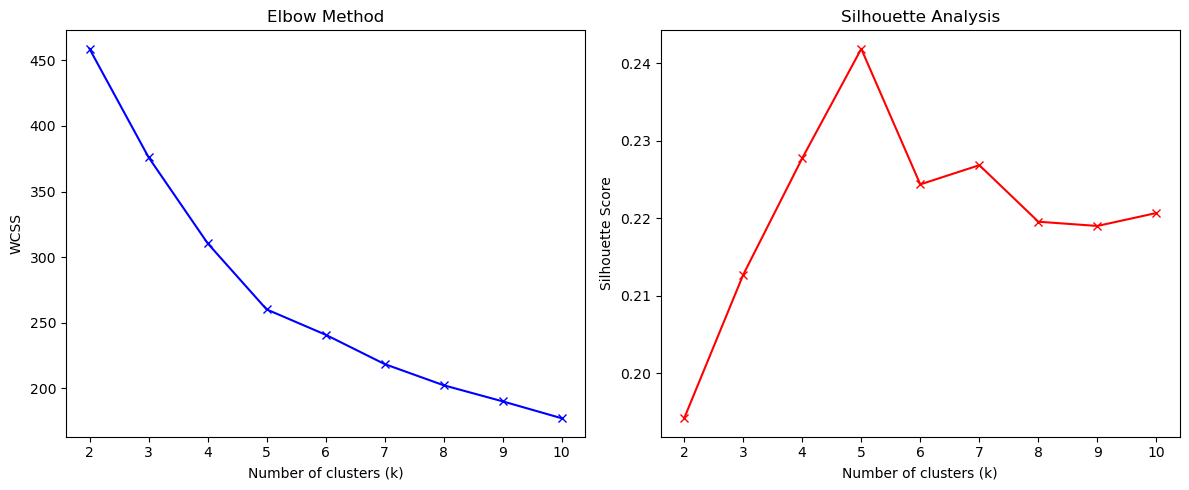

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load the data
df = df.copy()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
data = df[numeric_cols]

# Standardize
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

# Factor Analysis to get factor scores
n_factors = 4
fa = FactorAnalysis(n_components=n_factors, random_state=42)
factor_scores = fa.fit_transform(scaled_data)

# Determine optimal number of clusters using Elbow Method and Silhouette Score
wcss = []
silhouette_avg = []
range_n_clusters = range(2, 11)

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(factor_scores)
    wcss.append(kmeans.inertia_)
    silhouette_avg.append(silhouette_score(factor_scores, kmeans.labels_))

# Plot Elbow and Silhouette
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, wcss, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_avg, 'rx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')

plt.tight_layout()
plt.savefig('cluster_optimization.png')

# Choosing optimal k based on silhouette score (highest)
optimal_k = range_n_clusters[np.argmax(silhouette_avg)]
print(f"Optimal number of clusters based on Silhouette Score: {optimal_k}")

# Final Clustering
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_transform(factor_scores)
df['Cluster'] = kmeans_final.labels_

# Factor names from previous step
factor_names = [
    'Active Engagement', 
    'Domestic Affability', 
    'Protective Instinct', 
    'Grooming & Maintenance'
]
factor_df = pd.DataFrame(factor_scores, columns=factor_names)
factor_df['Cluster'] = kmeans_final.labels_
factor_df['Breed'] = df['Breed']

# Calculate cluster means
cluster_summary = factor_df.groupby('Cluster')[factor_names].mean()
print("\nCluster Means for each Factor:")
print(cluster_summary)

# Save the clustered data
df.to_csv('breed_traits_clustered.csv', index=False)

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import KMeans

# 1. Load data
df = df.copy()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 2. Replicate Factor and Cluster Analysis
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

# Factors: Engagement, Affability, Protection, Maintenance
fa = FactorAnalysis(n_components=4, random_state=42)
factor_scores = fa.fit_transform(scaled_data)

# Cluster the breeds
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(factor_scores)

# 3. Extract specific data for Great Pyrenees
# Note: The CSV uses non-breaking spaces (\xa0) in breed names
target_breed = 'Great\xa0Pyrenees' 
pyrenees_stats = df[df['Breed'] == target_breed].iloc[0]

# 4. Generate summary based on metrics
print(f"Breed: {pyrenees_stats['Breed']}")
print(f"Cluster: {pyrenees_stats['Cluster']} (Versatile Guardians)")
print("-" * 30)
print(f"Top Strengths: Watchdog Nature ({pyrenees_stats['Watchdog/Protective Nature']}/5), "
      f"Affection ({pyrenees_stats['Affectionate With Family']}/5)")
print(f"Average Traits: Energy ({pyrenees_stats['Energy Level']}/5), "
      f"Trainability ({pyrenees_stats['Trainability Level']}/5)")

Breed: Great Pyrenees
Cluster: 2 (Versatile Guardians)
------------------------------
Top Strengths: Watchdog Nature (5/5), Affection (5/5)
Average Traits: Energy (3/5), Trainability (3/5)


C:\Users\amaca253\AppData\Local\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [4]:
import pandas as pd

# Define names and 3-sentence descriptions based on factor score analysis
cluster_info = {
    0: {
        "Name": "Independent Workers",
        "Description": "These breeds exhibit high levels of mental and physical energy while maintaining a more reserved and independent relationship with their families. Their strengths lie in their high trainability and tireless work ethic, making them excellent candidates for specialized tasks. However, they may struggle in typical family settings due to their lower levels of natural affection and social openness."
    },
    1: {
        "Name": "Versatile Guardians",
        "Description": "This group represents highly engaged and affectionate breeds that possess strong protective instincts for their homes. They excel at providing both loyal companionship and a secure environment, balancing playfulness with a watchful nature. A potential drawback is their high demand for attention and mental stimulation to prevent destructive behaviors."
    },
    2: {
        "Name": "Reserved Companions",
        "Description": "These breeds are characterized by lower energy levels and a more stoic temperament, often appearing less responsive to family-oriented activities. Their primary strength is their calm and low-intensity presence, which can suit a quiet or less active lifestyle. Their weaknesses include a lower drive for training and play, which might make them seem disinterested to active owners."
    },
    3: {
        "Name": "High-Maintenance Beauties",
        "Description": "This cluster is primarily defined by significant grooming requirements and a steady, middle-of-the-road temperament across most other traits. They are exceptionally well-suited for owners who enjoy the process of aesthetic upkeep and a predictable, moderately affectionate companion. Conversely, the significant time and financial investment required for their coat care can be a burden for many."
    },
    4: {
        "Name": "Gentle Socialites",
        "Description": "These breeds are characterized by very high levels of family affability and a remarkably low protective instinct, making them incredibly friendly to everyone. Their greatest strength is their extreme friendliness and safety around strangers, making them ideal for social environments and multi-pet households. On the downside, they lack the instinct to act as a watchdog, offering little to no protection for the home."
    }
}

# Load the clustered data (from previous step)
df = pd.read_csv('breed_traits_clustered.csv')

# Apply the names and descriptions to the dataframe
df['Cluster Name'] = df['Cluster'].map(lambda x: cluster_info[x]['Name'])
df['Cluster Description'] = df['Cluster'].map(lambda x: cluster_info[x]['Description'])

# Save the final labeled dataset
df.to_csv('labeled_breed_clusters.csv', index=False)

# Display a sample of the results
print(df[['Breed', 'Cluster Name', 'Cluster Description']].head())

                   Breed         Cluster Name  \
0  Retrievers (Labrador)  Reserved Companions   
1        French Bulldogs    Gentle Socialites   
2   German Shepherd Dogs  Reserved Companions   
3    Retrievers (Golden)    Gentle Socialites   
4               Bulldogs  Versatile Guardians   

                                 Cluster Description  
0  These breeds are characterized by lower energy...  
1  These breeds are characterized by very high le...  
2  These breeds are characterized by lower energy...  
3  These breeds are characterized by very high le...  
4  This group represents highly engaged and affec...  


In [7]:

# 5. Extract Great Pyrenees data
# Handling the non-breaking space often found in this specific CSV's breed names
target_breed = 'Great Pyrenees'
# Clean the breed names in the dataframe for easier matching
df['Breed_Clean'] = df['Breed'].str.replace('\xa0', ' ').str.strip()
pyrenees_stats = df[df['Breed_Clean'] == target_breed].iloc[0]

# 6. Generate the Summary
cluster_name = pyrenees_stats['Cluster Name']

summary = (
    f"The {target_breed} demonstrates exceptional strength in its protective instincts and family loyalty, "
    f"characterized by a maximum score in watchdog nature ({pyrenees_stats['Watchdog/Protective Nature']}/5) "
    f"and a high level of affection toward its family members ({pyrenees_stats['Affectionate With Family']}/5). "
    f"Statistically, the breed maintains an average profile regarding energy levels ({pyrenees_stats['Energy Level']}/5), "
    f"trainability ({pyrenees_stats['Trainability Level']}/5), and playfulness ({pyrenees_stats['Playfulness Level']}/5), "
    f"while its physical maintenance is marked by moderate shedding ({pyrenees_stats['Shedding Level']}/5) "
    f"and drooling ({pyrenees_stats['Drooling Level']}/5). "
    f"Ultimately, the {target_breed} is a devoted and composed \"{cluster_name},\" serving as a steadfast "
    f"protector with a calm presence in the home."
)

print(f"{target_breed} Summary")
print("-" * len(target_breed + " Summary"))
print(summary)

Great Pyrenees Summary
----------------------
The Great Pyrenees demonstrates exceptional strength in its protective instincts and family loyalty, characterized by a maximum score in watchdog nature (5/5) and a high level of affection toward its family members (5/5). Statistically, the breed maintains an average profile regarding energy levels (3/5), trainability (3/5), and playfulness (3/5), while its physical maintenance is marked by moderate shedding (3/5) and drooling (3/5). Ultimately, the Great Pyrenees is a devoted and composed "Versatile Guardians," serving as a steadfast protector with a calm presence in the home.
